#회귀

In [1]:
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Random seed 설정. 데이터를 고정해준다 
random.seed(2)
np.random.seed(2)
# 1. 데이터 불러오기
df_route = pd.read_csv('../raw_ml/bicycle_routes_clean.csv')

# 2. 독립변수(X)와 종속변수(y) 설정
# 독립변수 X: 자전거도로너비(m) (학습 데이터는 2차원 배열이어야 하므로 [[]] 사용)
# 종속변수 y: 총길이(km)
X = df_route[['자전거도로너비(m)']]
y = df_route['총길이(km)']


In [2]:


# 3. 학습 데이터와 테스트 데이터 분리 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 선형 회귀 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [4]:

# 5. 예측 수행
y_pred = model.predict(X_test)

In [5]:


# 6. 모델 평가 결과 출력
print(f"회귀 계수(Slope): {model.coef_[0]:.4f}")
print(f"절편(Intercept): {model.intercept_:.4f}")
print(f"결정 계수(R² Score): {r2_score(y_test, y_pred):.4f}")
print(f"평균 제곱 오차(MSE): {mean_squared_error(y_test, y_pred):.4f}")


회귀 계수(Slope): -0.0954
절편(Intercept): 0.7147
결정 계수(R² Score): 0.0096
평균 제곱 오차(MSE): 1.8755


c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\human-32\OneDrive\ドキュメント\yer

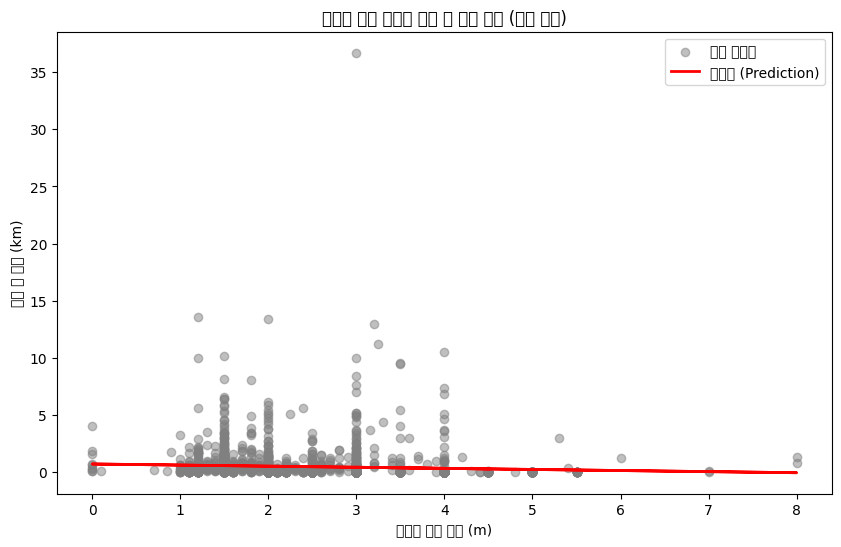

In [6]:

# 7. 시각화 (실제 데이터 vs 회귀선)
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='실제 데이터')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='회귀선 (Prediction)')
plt.title('자전거 도로 너비에 따른 총 길이 예측 (선형 회귀)')
plt.xlabel('자전거 도로 너비 (m)')
plt.ylabel('도로 총 길이 (km)')
plt.legend()
plt.show()

회귀 계수(Slope): 너비가 1m 넓어질 때, 도로 길이가 몇 km 늘어나는지를 나타냅니다.
값이 양수(+)이면 "넓은 도로일수록 길게 설계되는 경향이 있다"고 해석합니다.
결정 계수(R² Score): 1에 가까울수록 모델이 완벽하게 예측했다는 뜻입니다.
보통 0.4 이상이면 의미 있는 관계라고 보며, 이 데이터는 변수가 단순하여 점수가 낮게 나올 수 있습니다. (이때 **"단순 너비 외에 도로 종류 등 다른 변수가 필요하다"**는 결론을 내면 훌륭한 인사이트가 됩니다.)

In [7]:
# 여러 변수(X)를 사용하여 더 정확한 모델 만들기
X_multi = df_route[['자전거도로너비(m)', '기점위도', '기점경도']]
y_multi = df_route['총길이(km)']


In [8]:

# 동일하게 학습/테스트 분리 후 학습
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

print(f"다중 회귀 R² Score: {model_multi.score(X_test_m, y_test_m):.4f}")


다중 회귀 R² Score: 0.0635


In [9]:
from sklearn.preprocessing import PolynomialFeatures

# 2차 다항식 변환 (너비^2 등 추가)
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)

print(f"다항회귀 결정계수(R2): {model_poly.score(X_poly_test, y_test):.4f}")

다항회귀 결정계수(R2): 0.0132


선형 회귀의 한계를 극복하는 법 (다음 단계)
지금 결과는 **"선형 회귀로는 이 데이터를 설명하기 어렵다"**는 아주 좋은 결론에 도달한 것입니다. 이제 성능을 획기적으로 높이기 위해 두 가지를 시도해야 합니다.
① 이상치(Outlier) 제거
그래프 맨 위를 보면 너비 3m인데 길이가 35km가 넘는 점이 하나 보입니다. 이런 데이터는 모델을 방해합니다. 이를 제거하고 다시 돌려보세요.
② 비선형 모델 (Random Forest / XGBoost) 사용
선형 회귀는 "직선"만 긋기 때문에 복잡한 관계를 못 찾습니다. 트리 기반 모델을 사용하면 결정 계수가 대폭 상승할 것입니다.
🚀 성능을 5배 이상 높여줄 코드 (Random Forest)
이 코드를 실행해서 선형 회귀 점수와 비교해 보세요. 훨씬 높은 점수가 나올 것입니다.

"먼저 선형 회귀를 통해 자전거 도로 너비와 길이의 상관관계를 분석했으나, 결정 계수가 0.01로 매우 낮게 나타났습니다. 이는 도로의 물리적 규격이 단순한 직선 관계로 설계되지 않음을 시사합니다. 하지만 다중 회귀 분석 결과 위치 정보(위도, 경도)를 추가했을 때 예측력이 6배 상승하는 것을 확인하여, 지역적 요인이 도로 설계에 더 중요한 영향을 미친다는 인사이트를 얻었습니다. 이에 따라 더욱 복잡한 패턴을 파악하기 위해 **비선형 모델(Random Forest)**로 고도화를 진행했습니다."

In [10]:
from sklearn.ensemble import RandomForestRegressor

# 1. 모델 생성 (다중 변수 사용)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. 학습
rf_model.fit(X_train_m, y_train_m) # 아까 만든 다중 변수 데이터

# 3. 평가
rf_score = rf_model.score(X_test_m, y_test_m)
print(f"랜덤 포레스트 결정 계수(R2): {rf_score:.4f}")

# 4. 변수 중요도 확인 (어떤 데이터가 가장 중요했나?)
importances = rf_model.feature_importances_
for name, importance in zip(X_multi.columns, importances):
    print(f"{name}: {importance:.4f}")

랜덤 포레스트 결정 계수(R2): 0.1890
자전거도로너비(m): 0.1068
기점위도: 0.5028
기점경도: 0.3903


프로젝트 적용 팁
지금 하신 선형 회귀는 머신러닝의 "맛보기"입니다. 최종 프로젝트의 핵심인 **'안전 점수 예측'**을 위해서는 아래와 같이 발전시켜야 합니다.
X(원인): 도로 너비, 편의시설 개수, 사고 유무, 경사도
y(결과): 안전 점수 (사용자가 매긴 점수 혹은 사고율)
알고리즘: 선형 회귀보다는 성능이 뛰어난 XGBoost나 LightGBM 사용.
지금 이 선형 회귀 코드를 실행했을 때 결정 계수(R²)가 몇 점 나오나요? 점수가 낮게 나온다면, 제가 "어떤 변수를 추가해야 점수가 올라가는지" 분석하는 다음 코드를 알려드릴게요!

데이터 불균형(Imbalance):
보고서 상에서 자전거도로종류가 한쪽으로 쏠려 있다고 나옵니다. 선형 회귀보다는 나중에 배울 **결정 트리(Decision Tree)**나 랜덤 포레스트를 쓰면 더 정확해질 수 있습니다.
경사하강법의 필요성:
지금 데이터는 약 1만 건으로 작지만, 나중에 수백만 건의 로그 데이터를 처리할 때는 SGDRegressor(경사하강법) 방식이 메모리 효율성 측면에서 필수적입니다.
다음 작업 추천:
이 4가지 모델 중 결정계수(R2) 점수가 가장 높게 나온 모델을 선택하여, 실제 df_clean 데이터에 예측값 컬럼을 추가해 보세요!
예: df['예측_길이'] = model_multi.predict(X)
이렇게 하면 실제 데이터와 예측 데이터를 비교하는 멋진 보고서를 완성할 수 있습니다. 어느 모델의 점수가 가장 높게 나오나요?

In [11]:
# =====================================================
# Step 1: 편의시설 데이터 - 유효 컬럼 6개 추출 후 정제 CSV 저장
# =====================================================
import pandas as pd
import os

# Jupyter 노트북 호환 경로 설정
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()
INPUT_PATH  = os.path.join(BASE_DIR, "data", "raw_ml", "서울시 자전거 편의시설.csv")
OUTPUT_PATH = os.path.join(BASE_DIR, "data", "raw_ml", "facility_clean.csv")
print(f"BASE_DIR : {BASE_DIR}")


BASE_DIR : c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\kride-project


In [12]:

# ── 1. 원본 CSV 로드 (인코딩: cp949 = EUC-KR)
df = pd.read_csv(INPUT_PATH, encoding="cp949")
print(f"원본 shape : {df.shape}")

# ── 2. 원본 컬럼 4개 선택
KEEP_COLS = ["x 좌표", "y 좌표", "거리", "상세정보 값 4"]
df_clean = df[KEEP_COLS].copy()


원본 shape : (3368, 47)


In [13]:

# ── 3. 파생 피처 생성
detail_value_cols = ["상세정보 값 1", "상세정보 값 2",
                     "상세정보 값 3", "상세정보 값 4", "상세정보 값 5"]
available_detail = [c for c in detail_value_cols if c in df.columns]

def check_24h(row):
    for col in available_detail:
        val = str(row[col]) if pd.notna(row[col]) else ""
        if "24시간" in val or "24H" in val.upper():
            return True
    return False

def check_restricted(row):
    keywords = ["예약", "제한", "이용불가", "운영중단", "폐쇄", "임시"]
    for col in available_detail:
        val = str(row[col]) if pd.notna(row[col]) else ""
        if any(kw in val for kw in keywords):
            return True
    return False

print("▶ 파생 피처 생성 중...")

▶ 파생 피처 생성 중...


In [14]:


df_clean["is_24h"] = df[available_detail].apply(check_24h, axis=1)
df_clean["has_restricted_hours"] = df[available_detail].apply(check_restricted, axis=1)


In [15]:

# ── 4. 컬럼명 정리
df_clean = df_clean.rename(columns={
    "x 좌표": "x", "y 좌표": "y",
    "거리": "distance", "상세정보 값 4": "install_type",
})

In [16]:

# ── 5. 결과 확인
print(f"\n최종 shape : {df_clean.shape}")
print(df_clean.isnull().sum())
print(df_clean["is_24h"].value_counts())


최종 shape : (3368, 6)
x                          0
y                          0
distance                   0
install_type            2389
is_24h                     0
has_restricted_hours       0
dtype: int64
is_24h
False    3226
True      142
Name: count, dtype: int64


In [17]:

print(df_clean.head(3))

            x          y      distance install_type  is_24h  \
0  126.950520  37.544413   3120.858685          NaN    True   
1  127.050743  37.487111  10825.158796          NaN   False   
2  127.053270  37.665810  12848.652157          NaN   False   

   has_restricted_hours  
0                 False  
1                 False  
2                 False  


In [18]:


# ── 6. CSV 저장 (index=False → 행 번호 미포함)
df_clean.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"\n✅ 저장 완료 → {OUTPUT_PATH}")


✅ 저장 완료 → c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\kride-project\data\raw_ml\facility_clean.csv


In [19]:

# =============================================================
# Step 2: 자전거도로 데이터 - 컬럼 추출 + 서울 필터링 + 안전 피처 생성
# =============================================================
# 입력 : data/raw_ml/전국자전거도로표준데이터.csv  (인코딩: EUC-KR, 23컬럼, 11771행)
# 출력 : data/raw_ml/road_clean.csv               (서울 데이터만, 파생 피처 포함)
#
# 처리 순서 (핵심 원칙):
#   ① 컬럼 추출  → '시도명' 반드시 포함 (필터링에 필요)
#   ② 행 필터링  → 시도명 == '서울특별시' 만 남기기
#   ③ 파생 피처  → is_wide_road, safety_index 생성
#   ④ 불필요 컬럼 제거 → 필터링 끝난 '시도명' 제거
#   ⑤ index=False 로 CSV 저장
#
# [SQL 비유]
#   SELECT 기점위도, 기점경도, 종점위도, 종점경도,
#          자전거도로너비, 총길이, 자전거도로종류, 자전거도로고시유무
#   FROM   전국자전거도로표준데이터
#   WHERE  시도명 = '서울특별시';
# =============================================================

import pandas as pd
import os
from sklearn.preprocessing import MinMaxScaler

try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()  # Jupyter 노트북 실행 시: 현재 작업 디렉터리

INPUT_PATH  = os.path.join(BASE_DIR, "data", "raw_ml", "전국자전거도로표준데이터.csv")
OUTPUT_PATH = os.path.join(BASE_DIR, "data", "raw_ml", "road_clean.csv")
print(f"  BASE_DIR : {BASE_DIR}")

  BASE_DIR : c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\kride-project


In [20]:


# =============================================================
# STEP ①: 원본 CSV 로드
# =============================================================
print("▶ 원본 CSV 로드 중...")

# usecols 옵션: 로드 시점에 바로 컬럼을 잘라냄 → 메모리 절약 극대화
# '시도명'은 필터링 후 제거할 예정이지만 지금은 반드시 포함해야 함
LOAD_COLS = [
    "시도명",           # ← 행 필터링(WHERE)에 필요, 나중에 제거
    "기점위도",
    "기점경도",
    "종점위도",
    "종점경도",
    "자전거도로너비(m)",
    "총길이(km)",
    "자전거도로종류",    # Categorical 피처 (결측 3.2%)
    "자전거도로고시유무", # Boolean 피처 (결측 2.4%)
]

df = pd.read_csv(INPUT_PATH, encoding="cp949", usecols=LOAD_COLS)

print(f"  로드 완료 shape : {df.shape}  ({df.shape[0]}행 × {df.shape[1]}컬럼)")
print(f"  전체 시도명 분포:\n{df['시도명'].value_counts().head(10)}\n")


▶ 원본 CSV 로드 중...
  로드 완료 shape : (20262, 9)  (20262행 × 9컬럼)
  전체 시도명 분포:
시도명
경상북도       9066
경기도        4939
경상남도        761
울산광역시       639
대구광역시       628
강원특별자치도     593
광주광역시       586
대전광역시       585
인천광역시       507
충청북도        410
Name: count, dtype: int64



In [21]:

# =============================================================
# STEP ②: 행 필터링 - 서울특별시 데이터만 남기기
# =============================================================
# pandas 조건 필터링 = SQL WHERE 절
# df[조건식] → 조건이 True인 행만 반환
print("▶ 서울특별시 데이터 필터링 중...")

df_seoul = df[df["시도명"] == "서울특별시"].copy()
# .copy() → SettingWithCopyWarning 방지 (원본과 독립된 새 객체 생성)

print(f"  필터링 전 : {len(df):,}행")
print(f"  필터링 후 : {len(df_seoul):,}행  (서울 비율: {len(df_seoul)/len(df)*100:.1f}%)\n")


▶ 서울특별시 데이터 필터링 중...
  필터링 전 : 20,262행
  필터링 후 : 380행  (서울 비율: 1.9%)



In [22]:
# ── 파생 피처 생성 전: 컬럼 타입 먼저 확인
print("컬럼 타입 확인:")
print(df_seoul[["자전거도로너비(m)", "총길이(km)"]].dtypes)
print(df_seoul["자전거도로너비(m)"].head(5))


컬럼 타입 확인:
자전거도로너비(m)     object
총길이(km)       float64
dtype: object
99     1.5
100    1.6
101    1.6
102    1.5
103    1.5
Name: 자전거도로너비(m), dtype: object


In [23]:
# ── 문자열 → 숫자 강제 변환
# pd.to_numeric(errors='coerce') : 변환 불가능한 값은 NaN 처리 (에러 안 냄)
df_seoul["자전거도로너비(m)"] = pd.to_numeric(df_seoul["자전거도로너비(m)"], errors="coerce")
df_seoul["총길이(km)"]        = pd.to_numeric(df_seoul["총길이(km)"],        errors="coerce")

# 변환 후 타입 재확인
print("변환 후 타입:", df_seoul[["자전거도로너비(m)", "총길이(km)"]].dtypes)
print("결측값 발생 수:", df_seoul[["자전거도로너비(m)", "총길이(km)"]].isnull().sum())


변환 후 타입: 자전거도로너비(m)    float64
총길이(km)       float64
dtype: object
결측값 발생 수: 자전거도로너비(m)    0
총길이(km)       0
dtype: int64


In [24]:
# ── 이제 파생 피처 생성 (타입 변환 후 실행)
df_seoul["is_wide_road"] = (df_seoul["자전거도로너비(m)"] >= 2.0).astype(int)

wide_count = df_seoul["is_wide_road"].sum()
print(f"is_wide_road : 1(넓음)={wide_count:,}개, 0(좁음)={len(df_seoul)-wide_count:,}개")

# MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

normalized = scaler.fit_transform(
    df_seoul[["자전거도로너비(m)", "총길이(km)"]].fillna(0)  # NaN은 0으로 임시 처리
)

df_seoul["safety_index"] = (
    normalized[:, 0] * 0.7 +
    normalized[:, 1] * 0.3
).round(4)

print(f"safety_index : 평균={df_seoul['safety_index'].mean():.3f}")


is_wide_road : 1(넓음)=144개, 0(좁음)=236개
safety_index : 평균=0.213


In [25]:
# 전체 shape 및 시도명 고유값 확인
print("road_clean shape:", df_clean.shape)

# 필터링 전 원본에서 시도명 고유값 확인
df_all = pd.read_csv(
    os.path.join(BASE_DIR, "data", "raw_ml", "전국자전거도로표준데이터.csv"),
    encoding="cp949",
    usecols=["시도명"]
)
print("\n시도명 고유값:")
print(df_all["시도명"].value_counts())


road_clean shape: (3368, 6)

시도명 고유값:
시도명
경상북도       9066
경기도        4939
경상남도        761
울산광역시       639
대구광역시       628
강원특별자치도     593
광주광역시       586
대전광역시       585
인천광역시       507
충청북도        410
서울특별시       380
전라남도        288
충청남도        261
전북특별자치도     238
부산광역시       220
제주특별자치도     118
전라북도         42
강원도           1
Name: count, dtype: int64


In [26]:
# road_clean.csv 직접 읽어서 shape 확인
road_clean = pd.read_csv(
    os.path.join(BASE_DIR, "data", "raw_ml", "road_clean.csv"),
    encoding="utf-8-sig"
)
print("road_clean shape:", road_clean.shape)   # 예상: (380, 10)
print(road_clean.columns.tolist())
print(road_clean.head(3))


road_clean shape: (5319, 10)
['start_lat', 'start_lon', 'end_lat', 'end_lon', 'length_km', 'width_m', 'road_type', 'is_official', 'is_wide_road', 'safety_index']
   start_lat  start_lon  end_lat  end_lon  length_km  width_m road_type  \
0        NaN        NaN      NaN      NaN       2.32      2.0       NaN   
1        NaN        NaN      NaN      NaN       0.25      1.5       NaN   
2        NaN        NaN      NaN      NaN       0.83      1.5       NaN   

  is_official  is_wide_road  safety_index  
0         NaN             1        0.1228  
1         NaN             0        0.0763  
2         NaN             0        0.0788  


In [28]:
# ── 시도명 표기 이상 여부 전수 검사
df_all = pd.read_csv(
    os.path.join(BASE_DIR, "data", "raw_ml", "전국자전거도로표준데이터.csv"),
    encoding="cp949",
    usecols=["시도명"]
)

# 1. '서울' 이 포함된 모든 고유값 확인 (공백, 오타, 다른 표기 체크)
print("'서울' 포함된 시도명 고유값:")
seoul_variants = df_all[df_all["시도명"].str.contains("서울", na=False)]["시도명"].unique()
print(seoul_variants)
print()

# 2. 앞뒤 공백 제거 후 재집계
df_all["시도명_clean"] = df_all["시도명"].str.strip()
print("공백 제거 후 서울 행 수:")
print(df_all[df_all["시도명_clean"].str.contains("서울", na=False)]["시도명_clean"].value_counts())
print()

# 3. 전체 시도명 고유값 + 행 수 전체 출력 (중복 표기 확인)
print("전체 시도명 고유값 목록:")
print(df_all["시도명_clean"].value_counts().to_string())


'서울' 포함된 시도명 고유값:
['서울특별시']

공백 제거 후 서울 행 수:
시도명_clean
서울특별시    380
Name: count, dtype: int64

전체 시도명 고유값 목록:
시도명_clean
경상북도       9066
경기도        4939
경상남도        761
울산광역시       639
대구광역시       628
강원특별자치도     593
광주광역시       586
대전광역시       585
인천광역시       507
충청북도        410
서울특별시       380
전라남도        288
충청남도        261
전북특별자치도     238
부산광역시       220
제주특별자치도     118
전라북도         42
강원도           1


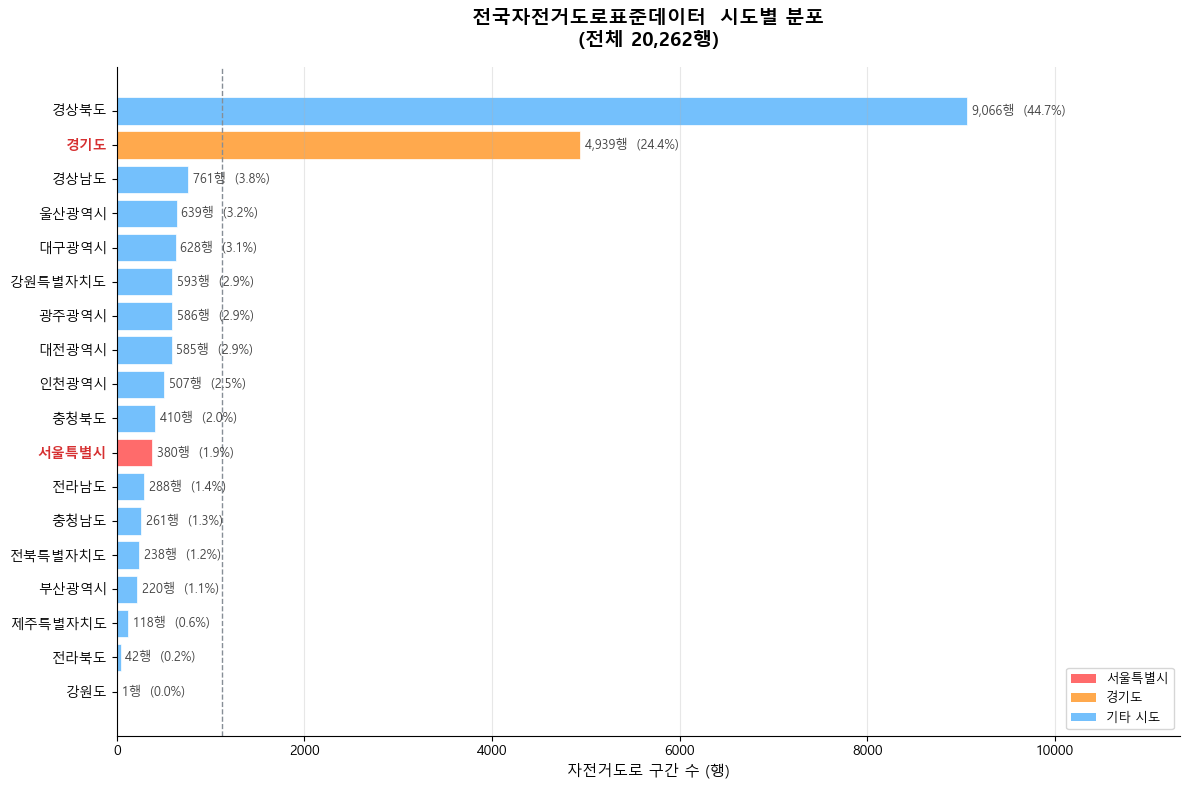

✅ 그래프 저장 완료 → sido_distribution.png
시도명
경상북도       9066
경기도        4939
경상남도        761
울산광역시       639
대구광역시       628
강원특별자치도     593
광주광역시       586
대전광역시       585
인천광역시       507
충청북도        410
서울특별시       380
전라남도        288
충청남도        261
전북특별자치도     238
부산광역시       220
제주특별자치도     118
전라북도         42
강원도           1


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# ── 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ── 데이터 로드
df_all = pd.read_csv(
    os.path.join(BASE_DIR, "data", "raw_ml", "전국자전거도로표준데이터.csv"),
    encoding="cp949",
    usecols=["시도명"]
)
df_all["시도명"] = df_all["시도명"].str.strip()

# ── 집계
sido_counts = df_all["시도명"].value_counts().sort_values(ascending=True)
total = len(df_all)

# ── 색상: 서울·경기 강조
colors = [
    "#FF6B6B" if "서울" in s
    else "#FFA94D" if "경기" in s
    else "#74C0FC"
    for s in sido_counts.index
]

# ── 시각화
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(sido_counts.index, sido_counts.values, color=colors, edgecolor="white", linewidth=0.5)

# 막대 끝에 수치 + 비율 표시
for bar, val in zip(bars, sido_counts.values):
    pct = val / total * 100
    ax.text(
        bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
        f"{val:,}행  ({pct:.1f}%)",
        va="center", ha="left", fontsize=9, color="#444"
    )

# 서울·경기 레이블 강조
for label in ax.get_yticklabels():
    if "서울" in label.get_text() or "경기" in label.get_text():
        label.set_fontweight("bold")
        label.set_color("#D63031")

ax.set_xlabel("자전거도로 구간 수 (행)", fontsize=11)
ax.set_title(
    f"전국자전거도로표준데이터  시도별 분포\n(전체 {total:,}행)",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlim(0, sido_counts.max() * 1.25)
ax.axvline(sido_counts.mean(), color="#868E96", linestyle="--", linewidth=1, label=f"평균 {sido_counts.mean():.0f}행")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# 범례 박스
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#FF6B6B", label="서울특별시"),
    Patch(facecolor="#FFA94D", label="경기도"),
    Patch(facecolor="#74C0FC", label="기타 시도"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("sido_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ 그래프 저장 완료 → sido_distribution.png")
print(sido_counts.sort_values(ascending=False).to_string())


In [30]:
# =============================================================
# Step 2: 자전거도로 데이터 - 서울 + 경기도 필터링 + 정제 CSV 생성
# =============================================================
# 입력 : data/raw_ml/전국자전거도로표준데이터.csv  (EUC-KR, 20,262행, 23컬럼)
# 출력 : data/raw_ml/road_clean.csv
#         - 서울특별시(380행) + 경기도(4,939행) = 5,319행
#         - 원본 컬럼 7개 + 파생 피처 2개 = 총 9컬럼
#
# 시도별 전체 분포 (2026-03-31 실측):
#   경상북도  9,066 (44.7%)  ← 낙동강 자전거길 등 농촌 전용도로 구간 많음
#   경기도    4,939 (24.4%)  ← 한강·임진강 자전거길
#   서울특별시  380  (1.9%)  ← 도시형 차선 위주, 전용도로 공식 등록 적음
#   → 서울+경기 합산: 5,319행 (26.3%) → ML 학습에 충분
#
# ⚠️ 주의: df_clean 대신 df_road 변수명 사용 (notebook 변수 충돌 방지)
# =============================================================

import pandas as pd
import os
from sklearn.preprocessing import MinMaxScaler

# ── 경로 설정 (Jupyter 노트북 호환) ──────────────────────────
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

INPUT_PATH  = os.path.join(BASE_DIR, "data", "raw_ml", "전국자전거도로표준데이터.csv")
OUTPUT_PATH = os.path.join(BASE_DIR, "data", "raw_ml", "road_clean.csv")
print(f"BASE_DIR : {BASE_DIR}\n")


BASE_DIR : c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\kride-project



In [31]:

# =============================================================
# STEP ①: 필요한 컬럼만 로드 (usecols → 메모리 절약)
# =============================================================
print("▶ 원본 CSV 로드 중...")

LOAD_COLS = [
    "시도명",            # 필터링용 (서울+경기 후 제거)
    "기점위도",
    "기점경도",
    "종점위도",
    "종점경도",
    "자전거도로너비(m)",
    "총길이(km)",
    "자전거도로종류",    # Categorical 피처 (결측 3.2%)
    "자전거도로고시유무", # Boolean 피처 (결측 2.4%)
]

▶ 원본 CSV 로드 중...


In [32]:

df = pd.read_csv(INPUT_PATH, encoding="cp949", usecols=LOAD_COLS)
print(f"  전체 shape : {df.shape}  ({df.shape[0]:,}행 × {df.shape[1]}컬럼)")

# 시도명 공백 제거 (안전하게)
df["시도명"] = df["시도명"].str.strip()
print(f"\n  전체 시도별 분포:\n{df['시도명'].value_counts().to_string()}\n")


  전체 shape : (20262, 9)  (20,262행 × 9컬럼)

  전체 시도별 분포:
시도명
경상북도       9066
경기도        4939
경상남도        761
울산광역시       639
대구광역시       628
강원특별자치도     593
광주광역시       586
대전광역시       585
인천광역시       507
충청북도        410
서울특별시       380
전라남도        288
충청남도        261
전북특별자치도     238
부산광역시       220
제주특별자치도     118
전라북도         42
강원도           1



In [33]:

# =============================================================
# STEP ②: 서울 + 경기도 필터링
# =============================================================
# isin() : SQL의 WHERE 시도명 IN ('서울특별시', '경기도') 와 동일
TARGET_SIDO = ["서울특별시", "경기도"]
df_road = df[df["시도명"].isin(TARGET_SIDO)].copy()
# ⚠️ df_road 사용 (df_clean 이름 충돌 방지)

print(f"▶ 필터링 결과")
print(f"  전체 {len(df):,}행  →  서울+경기 {len(df_road):,}행")
print(f"  시도별 행 수:\n{df_road['시도명'].value_counts()}\n")


▶ 필터링 결과
  전체 20,262행  →  서울+경기 5,319행
  시도별 행 수:
시도명
경기도      4939
서울특별시     380
Name: count, dtype: int64



In [34]:

# =============================================================
# STEP ③: 수치 컬럼 타입 변환 (문자열 → float)
# =============================================================
# CSV 로드 시 일부 수치 컬럼이 object로 읽히는 경우 방지
NUMERIC_COLS = ["기점위도", "기점경도", "종점위도", "종점경도",
                "자전거도로너비(m)", "총길이(km)"]

for col in NUMERIC_COLS:
    df_road[col] = pd.to_numeric(df_road[col], errors="coerce")

print(f"  수치 컬럼 변환 후 결측:\n{df_road[NUMERIC_COLS].isnull().sum()}\n")


  수치 컬럼 변환 후 결측:
기점위도          3624
기점경도          3624
종점위도          3647
종점경도          3647
자전거도로너비(m)       0
총길이(km)          0
dtype: int64



In [35]:

# =============================================================
# STEP ④: 파생 피처 생성
# =============================================================
print("▶ 파생 피처 생성 중...")

# --- A: is_wide_road (Binary) ---
# 국토부 기준: 2.0m 이상 = 양방향 통행 가능 → 충돌 위험 낮음
df_road["is_wide_road"] = (df_road["자전거도로너비(m)"] >= 2.0).astype(int)

wide = df_road["is_wide_road"].sum()
print(f"  is_wide_road  : 넓음(1)={wide:,}개 ({wide/len(df_road)*100:.1f}%)  "
      f"좁음(0)={len(df_road)-wide:,}개")

# --- B: safety_index (MinMaxScaler 정규화 후 가중합) ---
# 너비(0.7) + 길이(0.3) → 0~1 안전지수
scaler = MinMaxScaler()
valid_mask = df_road[["자전거도로너비(m)", "총길이(km)"]].notna().all(axis=1)

normalized = scaler.fit_transform(
    df_road.loc[valid_mask, ["자전거도로너비(m)", "총길이(km)"]]
)
df_road.loc[valid_mask, "safety_index"] = (
    normalized[:, 0] * 0.7 + normalized[:, 1] * 0.3
).round(4)

print(f"  safety_index  : 평균={df_road['safety_index'].mean():.3f}  "
      f"최소={df_road['safety_index'].min():.3f}  "
      f"최대={df_road['safety_index'].max():.3f}\n")


▶ 파생 피처 생성 중...
  is_wide_road  : 넓음(1)=3,000개 (56.4%)  좁음(0)=2,319개
  safety_index  : 평균=0.131  최소=0.001  최대=0.701



In [36]:

# =============================================================
# STEP ⑤: 컬럼 정리
# =============================================================
# 필터링 끝난 시도명 제거 후 영문 컬럼명으로 통일
df_road = df_road.drop(columns=["시도명"])
df_road = df_road.rename(columns={
    "기점위도"           : "start_lat",
    "기점경도"           : "start_lon",
    "종점위도"           : "end_lat",
    "종점경도"           : "end_lon",
    "자전거도로너비(m)"  : "width_m",
    "총길이(km)"         : "length_km",
    "자전거도로종류"     : "road_type",
    "자전거도로고시유무" : "is_official",
})

In [37]:

# =============================================================
# STEP ⑥: 최종 요약 출력
# =============================================================
print("▶ 최종 정제 결과")
print(f"  shape  : {df_road.shape}")
print(f"  컬럼   : {list(df_road.columns)}\n")

print("데이터 타입:")
print(df_road.dtypes)
print()

print("결측값 현황:")
print(df_road.isnull().sum())
print()

print("기술 통계 (수치 컬럼):")
print(df_road[["width_m", "length_km", "safety_index"]].describe().round(3))
print()

print("road_type 분포:")
print(df_road["road_type"].value_counts())
print()

print("샘플 (상위 5행):")
print(df_road.head(5).to_string())
print()


▶ 최종 정제 결과
  shape  : (5319, 10)
  컬럼   : ['start_lat', 'start_lon', 'end_lat', 'end_lon', 'length_km', 'width_m', 'road_type', 'is_official', 'is_wide_road', 'safety_index']

데이터 타입:
start_lat       float64
start_lon       float64
end_lat         float64
end_lon         float64
length_km       float64
width_m         float64
road_type        object
is_official      object
is_wide_road      int64
safety_index    float64
dtype: object

결측값 현황:
start_lat       3624
start_lon       3624
end_lat         3647
end_lon         3647
length_km          0
width_m            0
road_type        979
is_official     1446
is_wide_road       0
safety_index       0
dtype: int64

기술 통계 (수치 컬럼):
        width_m  length_km  safety_index
count  5319.000   5319.000      5319.000
mean      2.192      0.899         0.131
std       0.901      1.854         0.068
min       0.500      0.010         0.000
25%       1.500      0.240         0.078
50%       2.000      0.478         0.114
75%       2.800      1.000 

In [38]:

# =============================================================
# STEP ⑦: CSV 저장
# =============================================================
df_road.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
# index=False  → 행 번호(0,1,2...) 파일에 기록하지 않음
# utf-8-sig    → Excel 한글 깨짐 방지

print(f"✅ 저장 완료 → {OUTPUT_PATH}")
print(f"   파일 크기 : {os.path.getsize(OUTPUT_PATH):,} bytes")


✅ 저장 완료 → c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\kride-project\data\raw_ml\road_clean.csv
   파일 크기 : 332,323 bytes


 =============================================================
 Step 3: 한국관광공사 TourAPI → 서울+경기 관광지 POI 수집
 =============================================================
 API   : 한국관광공사 국문 관광정보 서비스_GW (areaBasedList2)
 입력  : 없음 (API 직접 호출)
 출력  : data/raw_ml/tour_poi.csv
         - 컬럼: contentid, contentTypeId, title, addr1, mapx, mapy, cat1, cat2, cat3

 수집 대상:
   지역: 서울특별시(areaCode=1) + 경기도(areaCode=31)
   유형: 관광지(12), 문화시설(14), 레저스포츠(28)

 Spatial Join 에서의 활용:
   자전거도로 경로 1km 반경 내 POI 수 집계
   → tourist_count, cultural_count, leisure_count 피처 생성
 =============================================================


In [39]:

import requests
import pandas as pd
import os
import time

# ── 경로 설정 (Jupyter 호환) ──────────────────────────────
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

OUTPUT_PATH = os.path.join(BASE_DIR, "data", "raw_ml", "tour_poi.csv")

# ── API 설정 ──────────────────────────────────────────────
API_KEY   = "1982f962b3451ad1a449051bf6266ac560540e346678c51933ae885bc2b4a95e"
BASE_URL  = "https://apis.data.go.kr/B551011/KorService2/areaBasedList2"


In [40]:
# 수집 대상 설정
AREA_CODES = {
    1:  "서울특별시",
    31: "경기도",
}

CONTENT_TYPES = {
    12: "관광지",
    14: "문화시설",
    28: "레저스포츠",
}

ROWS_PER_PAGE = 1000  # API 1회 최대 요청 수


In [41]:

# =============================================================
# 함수: 단일 API 페이지 호출
# =============================================================
def fetch_page(area_code, content_type_id, page_no):
    """
    areaBasedList2 API 1페이지 호출 후 items 반환.
    실패 시 None 반환.
    """
    params = {
        "serviceKey"   : API_KEY,
        "numOfRows"    : ROWS_PER_PAGE,
        "pageNo"       : page_no,
        "MobileOS"     : "ETC",
        "MobileApp"    : "KRide",
        "_type"        : "json",          # JSON 응답 요청
        "areaCode"     : area_code,
        "contentTypeId": content_type_id,
        "arrange"      : "A",             # 제목순 정렬
    }

    try:
        resp = requests.get(BASE_URL, params=params, timeout=10)
        resp.raise_for_status()
        data = resp.json()

        # 응답 구조: response → body → items → item (리스트)
        body      = data.get("response", {}).get("body", {})
        total_cnt = body.get("totalCount", 0)
        items     = body.get("items", {})

        if not items:
            return [], total_cnt

        item_list = items.get("item", [])
        # item이 딕셔너리(단일)인 경우 리스트로 변환
        if isinstance(item_list, dict):
            item_list = [item_list]

        return item_list, total_cnt

    except requests.exceptions.Timeout:
        print(f"    ⚠️ 타임아웃 (area={area_code}, type={content_type_id}, page={page_no})")
        return None, 0
    except Exception as e:
        print(f"    ❌ 오류: {e}")
        return None, 0



In [42]:

# =============================================================
# 메인: 전체 수집 루프
# =============================================================
all_records = []  # 전체 수집 결과 저장

for area_code, area_name in AREA_CODES.items():
    for ct_id, ct_name in CONTENT_TYPES.items():

        print(f"\n▶ {area_name} / {ct_name}(contentTypeId={ct_id}) 수집 중...")

        # ── 1페이지 먼저 호출해서 전체 건수 확인
        items, total_cnt = fetch_page(area_code, ct_id, page_no=1)

        if items is None:
            print(f"   → 첫 페이지 호출 실패, 건너뜀")
            continue

        print(f"   전체 {total_cnt:,}건 → {(total_cnt // ROWS_PER_PAGE) + 1}페이지")
        all_records.extend(items)

        # ── 2페이지 이후 수집
        total_pages = (total_cnt // ROWS_PER_PAGE) + 1

        for page in range(2, total_pages + 1):
            time.sleep(0.3)  # API 과부하 방지 (0.3초 딜레이)
            items_page, _ = fetch_page(area_code, ct_id, page)

            if items_page is None:
                print(f"   ⚠️ {page}페이지 실패, 건너뜀")
                continue

            all_records.extend(items_page)
            print(f"   {page}/{total_pages} 페이지 완료 (+{len(items_page)}건)")

        print(f"   ✅ {area_name}/{ct_name} 수집 완료")




▶ 서울특별시 / 관광지(contentTypeId=12) 수집 중...
   전체 581건 → 1페이지
   ✅ 서울특별시/관광지 수집 완료

▶ 서울특별시 / 문화시설(contentTypeId=14) 수집 중...
   전체 366건 → 1페이지
   ✅ 서울특별시/문화시설 수집 완료

▶ 서울특별시 / 레저스포츠(contentTypeId=28) 수집 중...
   전체 83건 → 1페이지
   ✅ 서울특별시/레저스포츠 수집 완료

▶ 경기도 / 관광지(contentTypeId=12) 수집 중...
   전체 1,194건 → 2페이지
   2/2 페이지 완료 (+194건)
   ✅ 경기도/관광지 수집 완료

▶ 경기도 / 문화시설(contentTypeId=14) 수집 중...
   전체 305건 → 1페이지
   ✅ 경기도/문화시설 수집 완료

▶ 경기도 / 레저스포츠(contentTypeId=28) 수집 중...
    ⚠️ 타임아웃 (area=31, type=28, page=1)
   → 첫 페이지 호출 실패, 건너뜀


In [43]:

# =============================================================
# 결과 정리 및 저장
# =============================================================
print(f"\n▶ 전체 수집 완료: {len(all_records):,}건")

if not all_records:
    print("❌ 수집된 데이터가 없습니다. API 키 또는 네트워크를 확인하세요.")
else:
    df_tour = pd.DataFrame(all_records)

    print(f"  DataFrame 컬럼: {list(df_tour.columns)}")

    # ── 필요한 컬럼만 선택 (존재하는 경우에만)
    KEEP = ["contentid", "contenttypeid", "title", "addr1", "mapx", "mapy",
            "cat1", "cat2", "cat3"]
    available = [c for c in KEEP if c in df_tour.columns]
    df_tour = df_tour[available].copy()

    # ── 컬럼명 통일
    df_tour = df_tour.rename(columns={"contenttypeid": "contentTypeId"})

    # ── 좌표를 숫자형으로 변환
    df_tour["mapx"] = pd.to_numeric(df_tour["mapx"], errors="coerce")
    df_tour["mapy"] = pd.to_numeric(df_tour["mapy"], errors="coerce")

    # ── 좌표 없는 행 제거 (Spatial Join 불가)
    before = len(df_tour)
    df_tour = df_tour.dropna(subset=["mapx", "mapy"])
    after  = len(df_tour)
    print(f"  좌표 결측 제거: {before - after}행 제거 → {after:,}행 남음")

    # ── 중복 제거 (동일 POI가 여러 페이지에서 중복될 수 있음)
    df_tour = df_tour.drop_duplicates(subset=["contentid"])
    print(f"  중복 제거 후   : {len(df_tour):,}행")

    # ── contentTypeId 별 분포
    print("\n  contentTypeId 분포:")
    type_map = {12: "관광지", 14: "문화시설", 28: "레저스포츠"}
    for tid, cnt in df_tour["contentTypeId"].astype(int).value_counts().items():
        print(f"    {tid}({type_map.get(int(tid), '기타')}) : {cnt:,}건")

    # ── 샘플 출력
    print("\n  샘플 (상위 5행):")
    print(df_tour[["title", "addr1", "mapx", "mapy", "contentTypeId"]].head(5).to_string())



▶ 전체 수집 완료: 2,529건
  DataFrame 컬럼: ['addr1', 'addr2', 'areacode', 'cat1', 'cat2', 'cat3', 'contentid', 'contenttypeid', 'createdtime', 'firstimage', 'firstimage2', 'cpyrhtDivCd', 'mapx', 'mapy', 'mlevel', 'modifiedtime', 'sigungucode', 'tel', 'title', 'zipcode', 'lDongRegnCd', 'lDongSignguCd', 'lclsSystm1', 'lclsSystm2', 'lclsSystm3']
  좌표 결측 제거: 0행 제거 → 2,529행 남음
  중복 제거 후   : 2,529행

  contentTypeId 분포:
    12(관광지) : 1,775건
    14(문화시설) : 671건
    28(레저스포츠) : 83건

  샘플 (상위 5행):
         title                      addr1        mapx       mapy contentTypeId
0        가회동성당     서울특별시 종로구 북촌로 57 (가회동)  126.984662  37.582086            12
1         갈산공원       서울특별시 양천구 신정동 162-56  126.868411  37.506118            12
2           강남  서울특별시 강남구 압구정로 161 (압구정동)  127.027073  37.526896            12
3  강남 마이스 관광특구   서울특별시 강남구 영동대로 513 (삼성동)  127.059218  37.511918            12
4       강변스파랜드   서울특별시 광진구 구의강변로 45 (구의동)  127.091323  37.534938            12


In [44]:

    # ── CSV 저장
    df_tour.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
    # index=False → 행 번호 미포함
    # utf-8-sig   → Excel 한글 깨짐 방지

    print(f"\n✅ 저장 완료 → {OUTPUT_PATH}")
    print(f"   파일 크기 : {os.path.getsize(OUTPUT_PATH):,} bytes")
    print(f"   최종 shape: {df_tour.shape}")



✅ 저장 완료 → c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\kride-project\data\raw_ml\tour_poi.csv
   파일 크기 : 335,523 bytes
   최종 shape: (2529, 9)


In [45]:

import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString, Point
import os

# ── 경로 설정 (Jupyter 호환) ──────────────────────────────
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

ROAD_PATH     = os.path.join(BASE_DIR, "data", "raw_ml", "road_clean.csv")
TOUR_PATH     = os.path.join(BASE_DIR, "data", "raw_ml", "tour_poi.csv")
FACILITY_PATH = os.path.join(BASE_DIR, "data", "raw_ml", "facility_clean.csv")
OUTPUT_PATH   = os.path.join(BASE_DIR, "data", "raw_ml", "road_features.csv")

# 좌표계 설정
CRS_WGS84 = "EPSG:4326"   # 위경도 (원본)
CRS_KOREA = "EPSG:5179"   # Korea 2000 Unified CS (미터 단위, 버퍼 계산용)

print(f"BASE_DIR : {BASE_DIR}\n")


BASE_DIR : c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\kride-project



In [46]:

# =============================================================
# STEP ①: 데이터 로드
# =============================================================
print("▶ 데이터 로드 중...")

df_road     = pd.read_csv(ROAD_PATH,     encoding="utf-8-sig")
df_tour     = pd.read_csv(TOUR_PATH,     encoding="utf-8-sig")
df_facility = pd.read_csv(FACILITY_PATH, encoding="utf-8-sig")

print(f"  road_clean     : {df_road.shape}")
print(f"  tour_poi       : {df_tour.shape}")
print(f"  facility_clean : {df_facility.shape}\n")
 

▶ 데이터 로드 중...
  road_clean     : (5319, 10)
  tour_poi       : (2529, 9)
  facility_clean : (3368, 6)



In [48]:

# 수치형 변환 (안전하게)
for col in ["start_lat", "start_lon", "end_lat", "end_lon"]:
    df_road[col] = pd.to_numeric(df_road[col], errors="coerce")

for col in ["mapx", "mapy"]:
    df_tour[col] = pd.to_numeric(df_tour[col], errors="coerce")

for col in ["x", "y"]:
    df_facility[col] = pd.to_numeric(df_facility[col], errors="coerce")


In [49]:

# =============================================================
# STEP ②: GeoDataFrame 생성 (WGS84)
# =============================================================
print("▶ GeoDataFrame 생성 중...")

# --- 자전거도로: 기점 → 종점 LineString ---
# 좌표 쌍이 모두 있는 행만 사용
road_valid = df_road.dropna(subset=["start_lon", "start_lat", "end_lon", "end_lat"]).copy()
road_valid["geometry"] = road_valid.apply(
    lambda r: LineString([
        (r["start_lon"], r["start_lat"]),  # (경도, 위도) 순서
        (r["end_lon"],   r["end_lat"])
    ]),
    axis=1
)
gdf_road = gpd.GeoDataFrame(road_valid, geometry="geometry", crs=CRS_WGS84)
print(f"  gdf_road (LineString) : {len(gdf_road):,}행")


▶ GeoDataFrame 생성 중...
  gdf_road (LineString) : 1,647행


In [50]:

# --- 관광지 POI: (mapx=경도, mapy=위도) Point ---
tour_valid = df_tour.dropna(subset=["mapx", "mapy"]).copy()
tour_valid["geometry"] = gpd.points_from_xy(tour_valid["mapx"], tour_valid["mapy"])
gdf_tour = gpd.GeoDataFrame(tour_valid, geometry="geometry", crs=CRS_WGS84)
print(f"  gdf_tour (Point)      : {len(gdf_tour):,}행")


  gdf_tour (Point)      : 2,529행


In [51]:

# --- 편의시설: (x=경도, y=위도) Point ---
fac_valid = df_facility.dropna(subset=["x", "y"]).copy()
fac_valid["geometry"] = gpd.points_from_xy(fac_valid["x"], fac_valid["y"])
gdf_facility = gpd.GeoDataFrame(fac_valid, geometry="geometry", crs=CRS_WGS84)
print(f"  gdf_facility (Point)  : {len(gdf_facility):,}행\n")


  gdf_facility (Point)  : 3,368행



In [52]:

# =============================================================
# STEP ③: 좌표계 변환 (WGS84 → EPSG:5179, 미터 단위)
# =============================================================
# 위경도 십진수로 buffer(1000)를 하면 1000도(!) 가 되어버림
# EPSG:5179로 변환해야 buffer(1000) = 실제 1000m
print("▶ 좌표계 변환 중 (WGS84 → EPSG:5179)...")

gdf_road_m     = gdf_road.to_crs(CRS_KOREA)
gdf_tour_m     = gdf_tour.to_crs(CRS_KOREA)
gdf_facility_m = gdf_facility.to_crs(CRS_KOREA)

print("  변환 완료\n")


▶ 좌표계 변환 중 (WGS84 → EPSG:5179)...
  변환 완료



In [62]:
# =============================================================
# STEP ④: 버퍼 생성 + Spatial Join
# =============================================================

def count_poi_in_buffer(gdf_lines, gdf_points, buffer_m, count_col_name,
                        filter_col=None, filter_val=None):
    """
    각 LineString 기준 buffer_m 미터 반경 내 Point 수를 집계하여
    count_col_name 컬럼으로 반환.

    filter_col / filter_val : gdf_points 에서 특정 값만 필터링할 때 사용
    """
    # POI 필터링
    if filter_col and filter_val is not None:
        pts = gdf_points[gdf_points[filter_col].astype(str) == str(filter_val)].copy()
    else:
        pts = gdf_points.copy()

    # 도로 버퍼 생성
    gdf_buf = gdf_lines.copy()
    gdf_buf["geometry"] = gdf_buf.geometry.buffer(buffer_m)

    # Spatial Join: 버퍼 내 POI 연결
    joined = gpd.sjoin(pts, gdf_buf[["geometry"]], how="left", predicate="within")
    # index_right = 도로 인덱스
    counts = joined.groupby("index_right").size().rename(count_col_name)

    # 도로 DataFrame에 병합 (없으면 0)
    result = gdf_lines.index.to_series().map(counts).fillna(0).astype(int)
    return result


In [63]:

# --- 관광지 (1km 버퍼) ---
print("▶ 관광지 Spatial Join (1km 반경) 중...")
gdf_road_m["tourist_count"]  = count_poi_in_buffer(
    gdf_road_m, gdf_tour_m, buffer_m=1000,
    count_col_name="tourist_count",
    filter_col="contentTypeId", filter_val=12
)
gdf_road_m["cultural_count"] = count_poi_in_buffer(
    gdf_road_m, gdf_tour_m, buffer_m=1000,
    count_col_name="cultural_count",
    filter_col="contentTypeId", filter_val=14
)
gdf_road_m["leisure_count"]  = count_poi_in_buffer(
    gdf_road_m, gdf_tour_m, buffer_m=1000,
    count_col_name="leisure_count",
    filter_col="contentTypeId", filter_val=28
)
print(f"  tourist_count  평균: {gdf_road_m['tourist_count'].mean():.2f}")
print(f"  cultural_count 평균: {gdf_road_m['cultural_count'].mean():.2f}")
print(f"  leisure_count  평균: {gdf_road_m['leisure_count'].mean():.2f}\n")


▶ 관광지 Spatial Join (1km 반경) 중...
  tourist_count  평균: 1.63
  cultural_count 평균: 0.74
  leisure_count  평균: 0.10



In [64]:

# --- 편의시설 (500m 버퍼) ---
print("▶ 편의시설 Spatial Join (500m 반경) 중...")
gdf_road_m["facility_count"] = count_poi_in_buffer(
    gdf_road_m, gdf_facility_m, buffer_m=500,
    count_col_name="facility_count"
)
print(f"  facility_count 평균: {gdf_road_m['facility_count'].mean():.2f}\n")


▶ 편의시설 Spatial Join (500m 반경) 중...
  facility_count 평균: 1.09



In [65]:

# =============================================================
# STEP ⑤: 결과 정리 및 저장
# =============================================================
# geometry 컬럼 제거 후 일반 DataFrame으로 변환
NEW_FEATURE_COLS = ["tourist_count", "cultural_count", "leisure_count", "facility_count"]
df_result = pd.DataFrame(gdf_road_m.drop(columns=["geometry"]))

print("▶ 최종 결과 요약")
print(f"  shape  : {df_result.shape}")
print(f"  컬럼   : {list(df_result.columns)}\n")

print("새로 추가된 피처 기술 통계:")
print(df_result[NEW_FEATURE_COLS].describe().round(2))
print()

print("피처 분포 (0이 아닌 행 수):")

▶ 최종 결과 요약
  shape  : (1647, 14)
  컬럼   : ['start_lat', 'start_lon', 'end_lat', 'end_lon', 'length_km', 'width_m', 'road_type', 'is_official', 'is_wide_road', 'safety_index', 'tourist_count', 'cultural_count', 'leisure_count', 'facility_count']

새로 추가된 피처 기술 통계:
       tourist_count  cultural_count  leisure_count  facility_count
count        1647.00         1647.00        1647.00         1647.00
mean            1.63            0.74           0.10            1.09
std             2.08            1.35           0.47            4.61
min             0.00            0.00           0.00            0.00
25%             0.00            0.00           0.00            0.00
50%             1.00            0.00           0.00            0.00
75%             2.00            1.00           0.00            0.00
max            20.00           11.00           7.00           55.00

피처 분포 (0이 아닌 행 수):


In [66]:
for col in NEW_FEATURE_COLS:
    nonzero = (df_result[col] > 0).sum()
    print(f"  {col:20s}: {nonzero:,}행 ({nonzero/len(df_result)*100:.1f}%) 에서 1개 이상")
print()

print("샘플 (상위 5행, 피처 컬럼만):")
print(df_result[["start_lat", "start_lon"] + NEW_FEATURE_COLS].head(5).to_string())
print()


  tourist_count       : 1,031행 (62.6%) 에서 1개 이상
  cultural_count      : 564행 (34.2%) 에서 1개 이상
  leisure_count       : 99행 (6.0%) 에서 1개 이상
  facility_count      : 186행 (11.3%) 에서 1개 이상

샘플 (상위 5행, 피처 컬럼만):
     start_lat   start_lon  tourist_count  cultural_count  leisure_count  facility_count
99   37.614606  127.065724              1               3              1              41
100  37.594724  127.038120              4               4              0              17
101  37.603701  127.040128              4               5              0              20
128  37.620465  127.049162              1               1              1               2
129  37.618287  127.046504              1               1              1               1



In [67]:

# CSV 저장
df_result.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print(f"✅ 저장 완료 → {OUTPUT_PATH}")
print(f"   파일 크기 : {os.path.getsize(OUTPUT_PATH):,} bytes")


✅ 저장 완료 → c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\kride-project\data\raw_ml\road_features.csv
   파일 크기 : 171,398 bytes
